# Support Vector Machine #

In [91]:
#import libraries:
import pandas as pd

In [92]:
# Read .csv file:
dataset = pd.read_csv('insurance_pre.csv')
dataset.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [93]:
# Check the dataset:
dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

In [94]:
dataset.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges'], dtype='object')

In [95]:
dataset.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
charges     float64
dtype: object

In [96]:
# convert the categorical columns:
dataset = pd.get_dummies(dataset,drop_first=True,dtype=int)
dataset.head()

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0


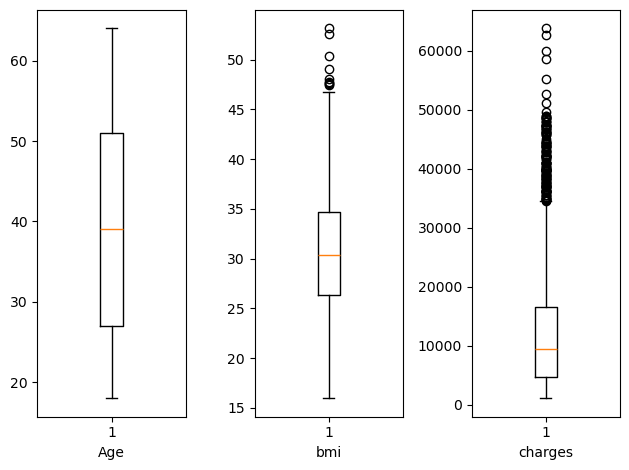

In [141]:
# Pre-processing the data:
#check the outlier:
import matplotlib.pyplot as plt
# plt.boxplot(dataset[['age','bmi','charges']])
# plt.show()
# plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.boxplot(dataset['age'])
plt.xlabel('Age')

plt.subplot(1,3,2)
plt.boxplot(dataset['bmi'])
plt.xlabel('bmi')

plt.subplot(1,3,3)
plt.boxplot(dataset['charges'])
plt.xlabel('charges')

plt.tight_layout()
plt.show()

In [98]:
# bmi has outlier:	In insurance charges dataset, high BMI or age can be real, so won’t touch it.

In [153]:
#IQR Capping:
Q1 = dataset['bmi'].quantile(0.25)
Q3 = dataset['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
higher = Q3 + 1.5 * IQR

dataset['bmi'] = dataset['bmi'].clip(lower,higher)
dataset['bmi']

0       27.900
1       33.770
2       33.000
3       22.705
4       28.880
         ...  
1333    30.970
1334    31.920
1335    36.850
1336    25.800
1337    29.070
Name: bmi, Length: 1338, dtype: float64

Text(0.5, 0, 'bmi')

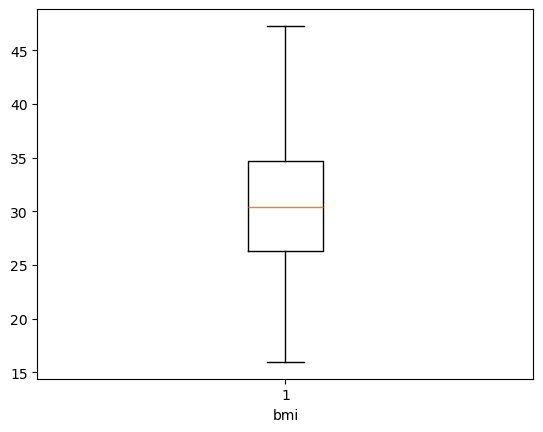

In [155]:
plt.boxplot(dataset['bmi'])
plt.xlabel('bmi')

Text(0.5, 0, 'charges')

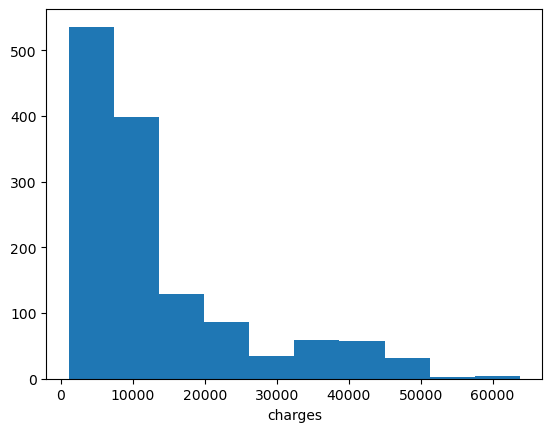

In [157]:
# Before outlier handling:
plt.hist(dataset['charges'])
plt.xlabel('charges')

In [163]:
# handling outlier in charges columns:
# Highly right-skewed
# High values are real & important (smokers, older people)
# These “outliers” carry business meaning
# so, i am go for Log transformation:
import numpy as np
dataset['charges_log'] = np.log1p(dataset['charges'])
dataset['charges_log'] 

0        9.734236
1        7.453882
2        8.400763
3        9.998137
4        8.260455
          ...    
1333     9.268755
1334     7.699381
1335     7.396847
1336     7.605365
1337    10.279948
Name: charges_log, Length: 1338, dtype: float64

Text(0.5, 0, 'charges_log')

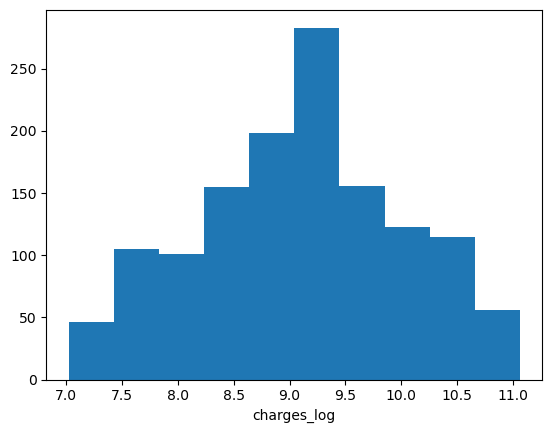

In [167]:
# After outlier handling:
plt.hist(dataset['charges_log'])
plt.xlabel('charges_log')

In [99]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [169]:
# Split Input and output columns:
independent = dataset[['age', 'bmi', 'children', 'sex_male', 'smoker_yes']]
dependent = dataset['charges_log']

In [171]:
#Split Train and test:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test = train_test_split(independent,dependent,test_size = 0.3,random_state = 0)

In [173]:
#Scale:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [175]:
# fetch the model:
from sklearn.svm import SVR # Regression
regressor = SVR()
# Train the model:
regressor = regressor.fit(x_train,y_train)
regressor
# Model Learned: 

SVR()

In [177]:
# training predicted value:
y_train_pred = regressor.predict(x_train)
y_train_pred

array([ 7.5968945 ,  8.73267578,  9.34090971,  8.96872275,  8.6034165 ,
        7.64122407, 10.29133476,  9.53364802,  8.91282245,  9.54585226,
        9.15439268,  9.45656874, 10.70426999,  8.30550265,  9.00741142,
        7.50317702,  9.65262756,  7.4296462 ,  8.90942441,  7.60226047,
        9.45643041,  8.50879174,  9.34963067, 10.6183837 ,  8.59364342,
       10.14011812,  9.75278133,  9.3926742 ,  9.04893499, 10.5655162 ,
        9.12155522,  8.20185329,  9.1879962 ,  9.74013556, 10.50006435,
        9.97437558,  9.20257173, 10.49503631,  8.37064535,  9.77363289,
        7.93048258, 10.4768213 ,  8.49939344,  9.39157475,  7.58554936,
       10.5858277 ,  9.17752425,  8.50245475,  8.3520646 ,  9.14761884,
        9.18665635,  9.00264663,  9.42167771,  8.32142556,  7.79953422,
        8.12248753,  8.23383485,  8.94071619, 10.3468466 ,  9.56756737,
        8.97024556,  9.15380392,  9.43373435,  7.45577508,  9.34518739,
        9.32995976,  8.44546799,  7.40461413, 10.80684561,  9.03

In [179]:
# Check the model learning quality using r_score:
from sklearn.metrics import r2_score
train_r2_score = r2_score(y_train,y_train_pred)
train_r2_score

0.826998542337732

In [182]:
# Test the Model:
y_test_pred = regressor.predict(x_test)
y_test_pred

array([ 9.27338192,  9.14773075, 10.78628573,  9.52048326,  9.22019888,
        8.30799881,  7.59206332,  9.4152645 ,  8.97540786,  8.60726938,
        8.88865684,  9.30322755,  8.99607276,  8.4205453 ,  9.98867683,
        9.36801845,  9.49715024,  8.05031491,  8.81936718, 10.08171493,
       10.05627525,  9.52136569,  9.2693878 , 10.21901847,  7.52358028,
        8.35852057,  8.09693202,  9.04617897,  8.31685285,  9.08333427,
        9.04545609, 10.75189583,  9.55370293,  9.33067667,  9.50401962,
        8.26675707,  9.13034813, 10.6717193 , 10.53513176,  7.66639949,
        8.55059526,  8.06395694, 10.05041096, 10.83222837, 10.55683427,
        8.16274074,  9.36646874,  8.88690229,  8.37494733,  9.49709623,
        7.81302112,  8.28444597, 10.24795577, 10.66563483,  9.44507996,
        7.9162622 ,  7.77378061,  9.14309308,  9.13908334,  9.56744041,
        7.40431325, 10.60093599,  9.63623334,  9.26017076,  9.30469299,
        9.30059669, 10.02702501, 10.48910748,  8.17610658,  9.00

In [186]:
# R2 score for checking the model quality:
test_r2_score = r2_score(y_test,y_test_pred)
test_r2_score

0.8398303404601464

In [198]:
print('Train R2_score:',train_r2_score)
print('Test R2_score:', test_r2_score)

Train R2_score: 0.826998542337732
Test R2_score: 0.8398303404601464
